# سوال اول - بخش دوم

In [77]:
import torch
import gzip
import struct
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, ConcatDataset, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as func

### زیربخش اول

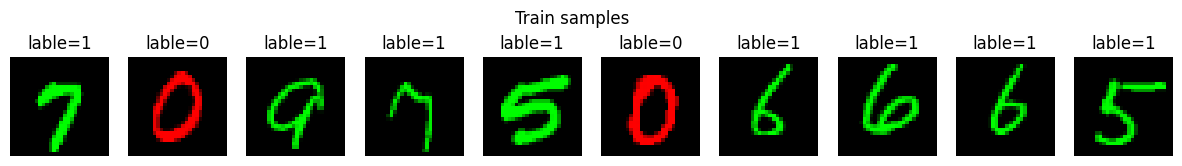

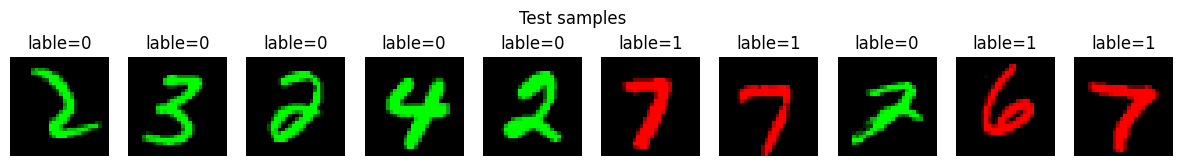

In [78]:
np.random.seed(30)
torch.manual_seed(30)

def load_images(path):
    with gzip.open(path, "rb") as file:
        _, num, rows, cols = struct.unpack(">IIII", file.read(16))
        data = np.frombuffer(file.read(), dtype=np.uint8)
        images = data.reshape(num, rows, cols)
    return images

def load_labels(path):
    with gzip.open(path, "rb") as file:
        struct.unpack(">II", file.read(8))
        labels = np.frombuffer(file.read(), dtype=np.uint8)
    return labels


x_train = load_images("./Mnist/train-images-idx3-ubyte.gz")
y_train = load_labels("./Mnist/train-labels-idx1-ubyte.gz")

x_test = load_images("./Mnist/t10k-images-idx3-ubyte.gz")
y_test = load_labels("./Mnist/t10k-labels-idx1-ubyte.gz")

def create_desired_dataset(images, labels, is_train):
    colored_images = []
    binary_labels = []
    color_labels = []

    for image, label in zip(images, labels):
        if label < 5:
            y = 0
        else:
            y = 1

        image = image.astype(np.float32) / 255.0
        rgb = np.zeros((3, 28, 28), dtype=np.float32)

        if is_train:
            aligned_data = np.random.rand() < 0.95

            if y == 0:
                color = 0 if aligned_data else 1  
            else:
                color = 1 if aligned_data else 0  

        else:
            color = 1 if y == 0 else 0

        if color == 0:
            rgb[0] = image   
        else:
            rgb[1] = image 

        colored_images.append(rgb)
        binary_labels.append(y)
        color_labels.append(color)

    colored_images = torch.tensor(np.array(colored_images), dtype=torch.float32)
    binary_labels = torch.tensor(binary_labels, dtype=torch.long)
    color_labels = torch.tensor(color_labels, dtype=torch.long)

    return TensorDataset(colored_images, binary_labels, color_labels)


train_dataset = create_desired_dataset(x_train, y_train, is_train=True)
test_dataset = create_desired_dataset(x_test, y_test, is_train=False)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


def plot_samples(dataset, title):
    plt.figure(figsize=(15, 2))
    indexes = np.random.choice(len(dataset), 10, replace=False)

    for i, idx in enumerate(indexes):
        image, label, _ = dataset[idx]
        image = image.permute(1, 2, 0).numpy()

        plt.subplot(1, 10, i + 1)
        plt.imshow(image)
        plt.title(f"lable={label.item()}")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()


plot_samples(train_dataset, "Train samples")
plot_samples(test_dataset, "Test samples")

### زیربخش دوم

In [79]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(2352, 128),
    nn.ReLU(),
    nn.Linear(128, 2)
)

def train_model(model, dataset, epochs):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    model.train()

    for _ in range(epochs):
        for image, labels, _ in dataset:

            outputs = model(image)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

def evaluate_model(model, dataset):
    correct_samples = 0
    total_samples = 0

    model.eval()
    
    with torch.no_grad():
        for image, labels, _ in dataset:
            outputs = model(image)
            predicts = outputs.argmax(dim=1)

            correct_samples += (predicts == labels).sum().item()
            total_samples += labels.size(0)

    return 100 * correct_samples / total_samples


train_model(model, train_loader, epochs=2)
train_accuracy = evaluate_model(model, train_loader)
test_accuracy = evaluate_model(model, test_loader)

print("ERM Model:")
print(f"\nERM Train Accuracy: {train_accuracy:.2f}%")
print(f"ERM Test Accuracy: {test_accuracy:.2f}%")

ERM Model:

ERM Train Accuracy: 97.69%
ERM Test Accuracy: 54.07%


### زیربخش سوم

In [80]:
def find_error_set(model, dataset):
    error_indexes = []

    model.eval()
    with torch.no_grad():
        start = 0

        for inputs, labels, _ in dataset:
            outputs = model(inputs)
            predicts = outputs.argmax(dim=1)

            wrong_samples = (predicts != labels)
            wrong_indexes = torch.where(wrong_samples)[0]

            for idx in wrong_indexes:
                error_indexes.append(start + idx.item())

            start += labels.size(0)

    return error_indexes


error_set = find_error_set(model, train_loader)

print("Train dataset size:", len(train_dataset))
print("Error set size:", len(error_set))

Train dataset size: 60000
Error set size: 1389


### زیربخش چهارم

In [81]:
U = 50
error_dataset = Subset(train_dataset, error_set)
weighted_train_dataset = ConcatDataset([train_dataset] + [error_dataset] * (U - 1))
weighted_train_loader = DataLoader(weighted_train_dataset, batch_size = 128, shuffle = True)

print("Original train dataset size:", len(train_dataset))
print("Error set size:", len(error_set))
print("Weighted dataset size:", len(weighted_train_dataset))

Original train dataset size: 60000
Error set size: 1389
Weighted dataset size: 128061


### زیربخش پنجم

In [82]:
jtt_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(2352, 128),
    nn.ReLU(),
    nn.Linear(128, 2)
)

train_model(jtt_model, weighted_train_loader, epochs=3)
jtt_train_accuracy = evaluate_model(jtt_model, train_loader)
jtt_test_accuracy = evaluate_model(jtt_model, test_loader)

print("JTT Model:")
print(f"\nJTT Train Accuracy: {jtt_train_accuracy:.2f}%")
print(f"JTT Test Accuracy: {jtt_test_accuracy:.2f}%")

JTT Model:

JTT Train Accuracy: 98.83%
JTT Test Accuracy: 78.50%


### زیربخش ششم

In [83]:
gce_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(2352, 128),
    nn.ReLU(),
    nn.Linear(128, 2)
)

def calculate_gce_loss(outputs, labels, q=0.7):
    probs = func.softmax(outputs, dim=1)
    correct_probs = probs.gather(1, labels.view(-1, 1)).squeeze()
    loss = (1 - correct_probs ** q) / q
    return loss.mean()

def train_gce_model(model, dataloader, epochs, q=0.7):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    model.train()

    for _ in range(epochs):
        for image, labels, _ in dataloader:

            outputs = model(image)
            loss = calculate_gce_loss(outputs, labels, q)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

train_gce_model(gce_model, train_loader, epochs=2, q=0.7)

gce_error_set = find_error_set(gce_model, train_loader)

print("\nGCE error set size:", len(gce_error_set))
print("Difference compared to standard ERM:", len(gce_error_set) - len(error_set))


GCE error set size: 2280
Difference compared to standard ERM: 891
